#  GPU Programming

The aim of the lab is understand GPU programming by implementing following tasks.
1. Write optimized matrix multiplication on GPU
2. 1x1 Convoultion is the most dominant operation in a modern deep neural network like Mobilenet_v1. Use optimized matrix multiplication for 1x1 Convolution
3. Benchmark throughput on a modern GPU hardware.



## Prerequisites

The following code installs triton. The DEVICE should show CUDA if GPU is selected as an accelerator. The Notebook needs CUDA support.

In [2]:
!pip install triton torchprofile -q
import torch
import triton
import triton.language as tl
import time

torch.manual_seed(0); torch.cuda.manual_seed_all(0)
DEVICE = triton.runtime.driver.active.get_active_torch_device()
print(DEVICE)

cuda:0


## Utilities

Following functions can be used for benchmarking your gpu implementation of matrix multiplication

In [3]:
# ---------------------------- Utils ----------------------------

def bench(fn, warmup=2, reps=20):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(reps):
        fn()
    torch.cuda.synchronize()
    end = time.time()
    return (end - start) * 1000 / reps  # ms

def gflops(N, time_ms):
    """GFLOPS for an N x N square matmul: FLOPs = 2 * N^3."""
    return 2 * N**3 / (time_ms * 1e-3) / 1e9

def gflops_gemm(M, N, K, time_ms):
    """GFLOPS for a general M x K @ K x N matmul: FLOPs = 2 * M * N * K."""
    return 2 * M * N * K / (time_ms * 1e-3) / 1e9

**Task 1** Find out the following information about the GPU from torch, datasheet, or wikipedia.
* GPU
* SRAM
* VRAM
* Streaming Multiprocessors
* Peak Performance (FP32)
* Peak Performance (FP16)

In [4]:
# TODO
props = torch.cuda.get_device_properties(0)
GPU_NAME = props.name

print(f"GPU                         : {GPU_NAME}")
print(f"Compute Capability          : {props.major}.{props.minor}")
print(f"Streaming Multiprocessors   : {props.multi_processor_count}")
print(f"VRAM (total)                : {props.total_memory / 1024**3:.2f} GiB")
print(f"Shared Memory / SM          : {props.shared_memory_per_block / 1024:.0f} KiB")
print(f"L2 Cache                    : {props.L2_cache_size / 1024**2:.2f} MiB")

# ---- Fill in from datasheet / wikipedia ----
PEAK_FP32_TFLOPS = 8.1    # e.g. T4 ~ 8.1, A100 ~ 19.5, H100 ~ 67
PEAK_FP16_TFLOPS = 65    # tensor-core
PEAK_BW = 320

print(f"\nPeak FP32 (datasheet)       : {PEAK_FP32_TFLOPS} TFLOPS")
print(f"Peak FP16 (tensor cores)    : {PEAK_FP16_TFLOPS} TFLOPS")
print(f"Peak FP16 (tensor cores)    : {PEAK_FP16_TFLOPS} TFLOPS")
print(f"Peak DRAM BW (datasheet)    : {PEAK_BW} GB/s\n")

GPU                         : Tesla T4
Compute Capability          : 7.5
Streaming Multiprocessors   : 40
VRAM (total)                : 14.56 GiB
Shared Memory / SM          : 48 KiB
L2 Cache                    : 4.00 MiB

Peak FP32 (datasheet)       : 8.1 TFLOPS
Peak FP16 (tensor cores)    : 65 TFLOPS
Peak FP16 (tensor cores)    : 65 TFLOPS
Peak DRAM BW (datasheet)    : 320 GB/s



# Matrix Multiplication

A simple matrix multiplication $C[m,n] = \sum A[m,k] * B[k,n]$ loads each element of A and B once per output element. Following is a naive implementation in triton which multiplies two 64x64 square matrices.
Assumption:
* Square matrix
* fp32 datatype

**Task 2**
* Execution Model: Which part of the following code runs on CPU and GPU respectively?
* Execution Model: How many triton programs are launched?
* Execution Model: What is the program_id of triton program which calculates C[1,1]
* Memory Model: What is total number of load and store from one triton program
* Memory Model: What is the total number of floating point operation per triton program

In [5]:
@triton.jit
def simple_matmul_kernel(a_ptr, b_ptr, c_ptr, N):
    pid_m = tl.program_id(0)   # row index
    pid_n = tl.program_id(1)   # column index

    acc = 0.0

    for k in range(N):
        a_val = tl.load(a_ptr + pid_m * N + k)
        b_val = tl.load(b_ptr + k * N + pid_n)
        acc += a_val * b_val

    tl.store(c_ptr + pid_m * N + pid_n, acc)

def simple_matmul(a, b):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=a.dtype)

    simple_matmul_kernel[(N, N)](
        a, b, c, N
    )

    return c

A = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5
torch.testing.assert_close(simple_matmul(A, B), torch.matmul(A, B), atol=1e-2, rtol=0)

# Benchmarking Performance

**Task 3**
* Measure mean GPU kernel time for matrix multiplication (N=1024) in milliseconds.
* What is the throughput of the naive GPU implementation in gflops?
* Is it higher compared to Optimized CPU implementation in Lab 2?


In [6]:
N = 1024
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5


t = bench(lambda: simple_matmul(A, B))

# TODO:
print(f"Kernel execution time: {t} ms")
print(f"Gflops: {gflops(N, t)} ")

Kernel execution time: 463.07575702667236 ms
Gflops: 4.63743483741972 


# Optimization


## Tiled Matrix Multiplication

block level data reuse.

Assumptions:
* Square tiles


In [7]:
@triton.jit
def simple_tiled_matmul_kernel(
    a_ptr, b_ptr, c_ptr,
    N,
    BLOCK: tl.constexpr,
):
    # ---- which tile of C this program computes ----
    pid = tl.program_id(0)

    tiles_per_row = N // BLOCK
    pid_m = pid // tiles_per_row
    pid_n = pid % tiles_per_row

    # ---- row/col indices of this tile ----
    offs_m = pid_m * BLOCK + tl.arange(0, BLOCK)
    offs_n = pid_n * BLOCK + tl.arange(0, BLOCK)

    # accumulator for C tile
    acc = tl.zeros((BLOCK, BLOCK), dtype=tl.float32)

    # ---- iterate over K tiles ----
    for k in range(0, N, BLOCK):

        offs_k = k + tl.arange(0, BLOCK)

        # load A and B tiles
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])

        # matrix multiply
        acc += tl.dot(a, b)

    # store result
    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)

def simple_tiled_matmul(a, BLOCK=64):
    N = a.shape[0]

    c = torch.empty((N, N), device=a.device, dtype=torch.float32)

    grid = ((N // BLOCK) * (N // BLOCK),)

    simple_tiled_matmul_kernel[grid](
        a, a, c,
        N,
        BLOCK=BLOCK,
        num_warps = 4,
    )

    return c

1. What block size leads to failure (block launch impossible as it exceeds shared memory capacity)
2. What block size (in powers of 2) and size of matrix leads to highest throughput?
3. Assuming FP32, what is the SRAM Usage per SM for the above block size
4. Is this kernel compute bound or memory bound
5. num warps = 4 leads to best occupancy. Why?

In [8]:
N = 2048
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

# Run kernel
#t = bench(lambda: simple_tiled_matmul(A, 64), 50, 200)
t = bench(lambda: torch.matmul(A,A), 50,200)

print(f"Kernel execution time: {t} ms")
print(f"Gflops: {gflops(N, t)} ")

Kernel execution time: 4.370388984680176 ms
Gflops: 3930.970273863899 


In [9]:
def kernel_info(jit_fn):
    """Return compile-time stats for any cached variant of jit_fn.
    Walks whichever cache structure this Triton version uses."""
    # Triton has used: `cache`, `device_caches` — find whichever exists.
    cache = None
    for attr in ("device_caches", "cache"):
        if hasattr(jit_fn, attr):
            cache = getattr(jit_fn, attr)
            break
    if not cache:
        return None

    # The cache is a nested mix of dicts / tuples / lists ending in a
    # CompiledKernel (which has a `.metadata` attribute). Walk recursively.
    def find_compiled(obj, depth=0):
        if depth > 5 or obj is None:
            return None
        if hasattr(obj, "metadata") and not isinstance(obj, (dict, list, tuple)):
            return obj
        if isinstance(obj, dict):
            for v in obj.values():
                r = find_compiled(v, depth + 1)
                if r is not None:
                    return r
        elif isinstance(obj, (tuple, list)):
            for v in obj:
                r = find_compiled(v, depth + 1)
                if r is not None:
                    return r
        return None

    k = find_compiled(cache)
    if k is None:
        return None
    md = k.metadata
    return dict(
        n_regs       = getattr(k,  "n_regs",     None),
        n_spills     = getattr(k,  "n_spills",   None),
        shared_bytes = getattr(md, "shared",     None),
        num_warps    = getattr(md, "num_warps",  None),
        num_stages   = getattr(md, "num_stages", None),
    )

In [10]:

A = torch.rand((2048, 2048), device="cuda", dtype=torch.float32)
simple_tiled_matmul(A, 64)
torch.cuda.synchronize()

info = kernel_info(simple_tiled_matmul_kernel)
print(info)

{'n_regs': 128, 'n_spills': 0, 'shared_bytes': 32768, 'num_warps': 4, 'num_stages': 3}


# Unit Test

In [11]:
A = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5

torch.testing.assert_close(
    simple_tiled_matmul(A, 64),   # ← cast back to FP32
    torch.matmul(A, A),
    atol=1e-1, rtol=1e-2,                            # ← also loosen tolerance
)
print("OK")

OK


# Benchmarking

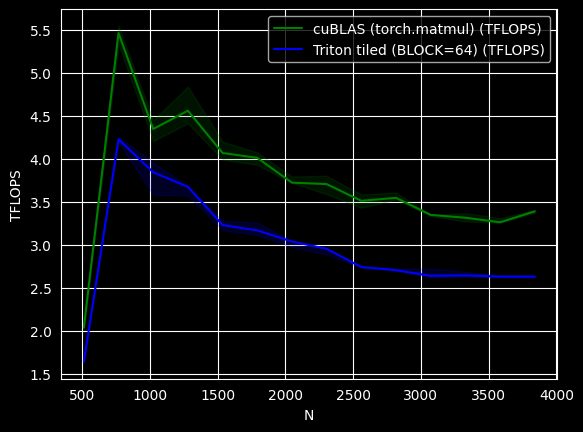

matmul-fp32-square:
         N  cuBLAS (torch.matmul) (TFLOPS)  Triton tiled (BLOCK=64) (TFLOPS)
0    512.0                        2.037059                          1.640002
1    768.0                        5.461333                          4.226236
2   1024.0                        4.345303                          3.842257
3   1280.0                        4.557758                          3.673131
4   1536.0                        4.066364                          3.228964
5   1792.0                        4.009717                          3.166732
6   2048.0                        3.721757                          3.037691
7   2304.0                        3.705090                          2.952914
8   2560.0                        3.510183                          2.741347
9   2816.0                        3.545429                          2.704249
10  3072.0                        3.346791                          2.639195
11  3328.0                        3.314071              

In [15]:
import triton
import triton.testing

configs = [
    triton.testing.Benchmark(
        x_names      = ["N"],
        x_vals       = [256 * i for i in range(2, 16)],   # 256, 384, ..., 4096
        line_arg     = "provider",
        line_vals    = ["torch", "tiled"],
        line_names   = ["cuBLAS (torch.matmul)", "Triton tiled (BLOCK=64)"],
        styles       = [("green", "-"), ("blue", "-")],
        ylabel       = "TFLOPS",
        plot_name    = "matmul-fp32-square",
        args         = {},
    ),
]


@triton.testing.perf_report(configs)
def benchmark(N, provider):
    a = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    b = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

    quantiles = [0.5, 0.2, 0.8]

    if provider == "torch":
        fn = lambda: torch.matmul(a, a)
    elif provider == "tiled":
        fn = lambda: simple_tiled_matmul(a, BLOCK=64)

    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=quantiles)
    perf = lambda ms: 2 * N * N * N * 1e-12 / (ms * 1e-3)   # TFLOPS
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)

In [22]:
torch.cuda.empty_cache()
N = 2048
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

# Single shot, fresh thermal state
ms = triton.testing.do_bench(lambda: simple_tiled_matmul(A, BLOCK=64),
                              warmup=10, rep=200, quantiles=None)
!nvidia-smi --query-gpu=name,power.limit,power.max_limit,clocks.max.gr \
            --format=csv,noheader
print(f"{N=}, {ms:.2f} ms, {2*N**3/(ms*1e-3)/1e12:.2f} TFLOPS")

Tesla T4, 70.00 W, 70.00 W, 1590 MHz
N=2048, 7.15 ms, 2.40 TFLOPS
